# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Music Streaming Habits Dataset](https://www.kaggle.com/datasets/uditjain13/music-streaming-habits-2026)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

/kaggle/input/datasets/uditjain13/music-streaming-habits-2026/music_streaming_habits_2026.csv


## Import CSV And convert to DataFrame

In [22]:
df = pd.read_csv('music_streaming_habits_2026.csv')

# Preprocessing

## Frist five row

In [23]:
df.head()

,listener_id,age,country,platform,subscription,top_genre,top_artist,daily_listening_minutes,songs_per_day,playlists_count,skip_rate_pct,discover_weekly_user,top_mood,uses_offline_mode,podcasts_too
0,1,24,Australia,Apple Music,Free,R&B,Kendrick Lamar,191,54,9,39.3,False,Sleep,False,True
1,2,21,Germany,Spotify,Free,Classical,Drake,249,68,10,18.3,True,Workout,True,True
2,3,32,Japan,Amazon Music,Free,Hip-Hop,Olivia Rodrigo,49,11,11,22.7,True,Sad,False,True
3,4,39,Japan,Apple Music,Free,Pop,Burna Boy,96,22,8,29.4,True,Sad,True,False
4,5,23,India,Spotify,Family,Country,Olivia Rodrigo,100,24,13,37.7,True,Workout,True,True


## last Five row

In [24]:
df.tail()

,listener_id,age,country,platform,subscription,top_genre,top_artist,daily_listening_minutes,songs_per_day,playlists_count,skip_rate_pct,discover_weekly_user,top_mood,uses_offline_mode,podcasts_too
3995,3996,26,France,Spotify,Family,Pop,SZA,197,55,6,15.3,False,Workout,True,False
3996,3997,35,Germany,YouTube Music,Free,Rock,Ariana Grande,320,77,13,9.2,True,Sad,False,True
3997,3998,43,India,Apple Music,Free,Hip-Hop,Dua Lipa,99,38,5,14.0,False,Happy,True,True
3998,3999,26,India,Apple Music,Student,Indie,SZA,76,31,7,36.1,False,Happy,False,False
3999,4000,24,UK,Spotify,Premium,Hip-Hop,Dua Lipa,161,49,9,37.8,True,Workout,False,False


## Shape of our dataset

In [25]:
df.shape

(4000, 15)

## List out all columns

In [26]:
df.columns

Index(['listener_id', 'age', 'country', 'platform', 'subscription',
       'top_genre', 'top_artist', 'daily_listening_minutes', 'songs_per_day',
       'playlists_count', 'skip_rate_pct', 'discover_weekly_user', 'top_mood',
       'uses_offline_mode', 'podcasts_too'],
      dtype='object')

## Datatype of each columns

In [27]:
df.dtypes

listener_id                  int64
age                          int64
country                     object
platform                    object
subscription                object
top_genre                   object
top_artist                  object
daily_listening_minutes      int64
songs_per_day                int64
playlists_count              int64
skip_rate_pct              float64
discover_weekly_user          bool
top_mood                    object
uses_offline_mode             bool
podcasts_too                  bool
dtype: object

## Information of all Columns

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   listener_id              4000 non-null   int64  
 1   age                      4000 non-null   int64  
 2   country                  4000 non-null   object 
 3   platform                 4000 non-null   object 
 4   subscription             4000 non-null   object 
 5   top_genre                4000 non-null   object 
 6   top_artist               4000 non-null   object 
 7   daily_listening_minutes  4000 non-null   int64  
 8   songs_per_day            4000 non-null   int64  
 9   playlists_count          4000 non-null   int64  
 10  skip_rate_pct            4000 non-null   float64
 11  discover_weekly_user     4000 non-null   bool   
 12  top_mood                 4000 non-null   object 
 13  uses_offline_mode        4000 non-null   bool   
 14  podcasts_too            

## Check Null Value

In [29]:
df.isnull().sum()

listener_id                0
age                        0
country                    0
platform                   0
subscription               0
top_genre                  0
top_artist                 0
daily_listening_minutes    0
songs_per_day              0
playlists_count            0
skip_rate_pct              0
discover_weekly_user       0
top_mood                   0
uses_offline_mode          0
podcasts_too               0
dtype: int64

## Check Dupicate Value

In [30]:
df.duplicated().sum()

np.int64(0)

## Summary

In [31]:
df.describe()

,listener_id,age,daily_listening_minutes,songs_per_day,playlists_count,skip_rate_pct
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,2000.500000,27.849000,138.702750,39.137500,8.994500,28.163375
std,1154.844867,8.595881,86.296023,25.046296,3.027914,11.815850
min,1.000000,13.000000,5.000000,1.000000,1.000000,0.000000
25%,1000.750000,22.000000,74.000000,21.000000,7.000000,20.000000
50%,2000.500000,28.000000,122.000000,35.000000,9.000000,28.100000
75%,3000.250000,34.000000,185.000000,52.250000,11.000000,36.300000
max,4000.000000,57.000000,697.000000,198.000000,22.000000,70.900000


# EDA

In [32]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

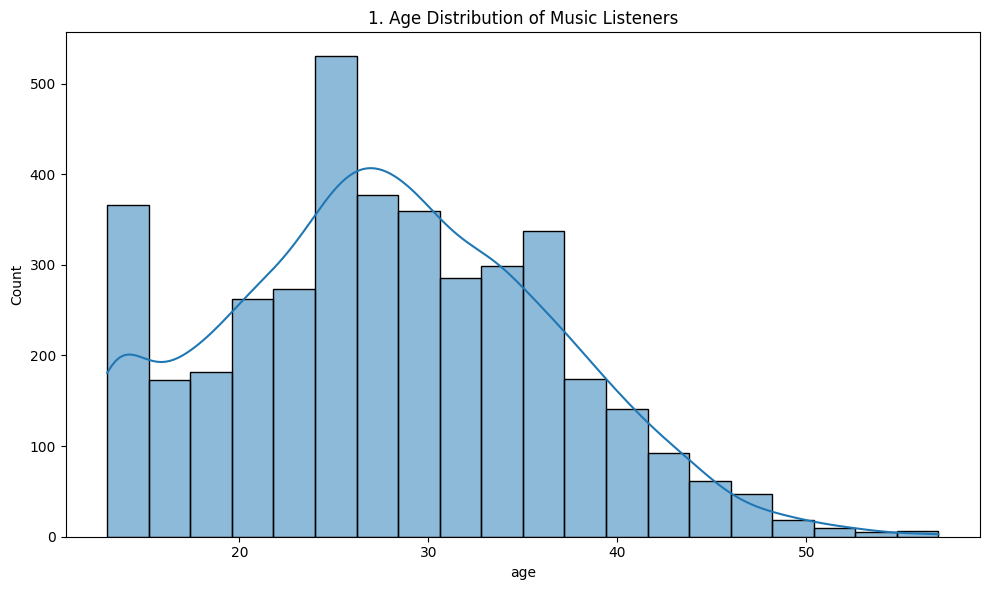

In [33]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='age', bins=20, kde=True)
plt.title(f'{plot_no}. Age Distribution of Music Listeners')
show_fig()
plot_no += 1

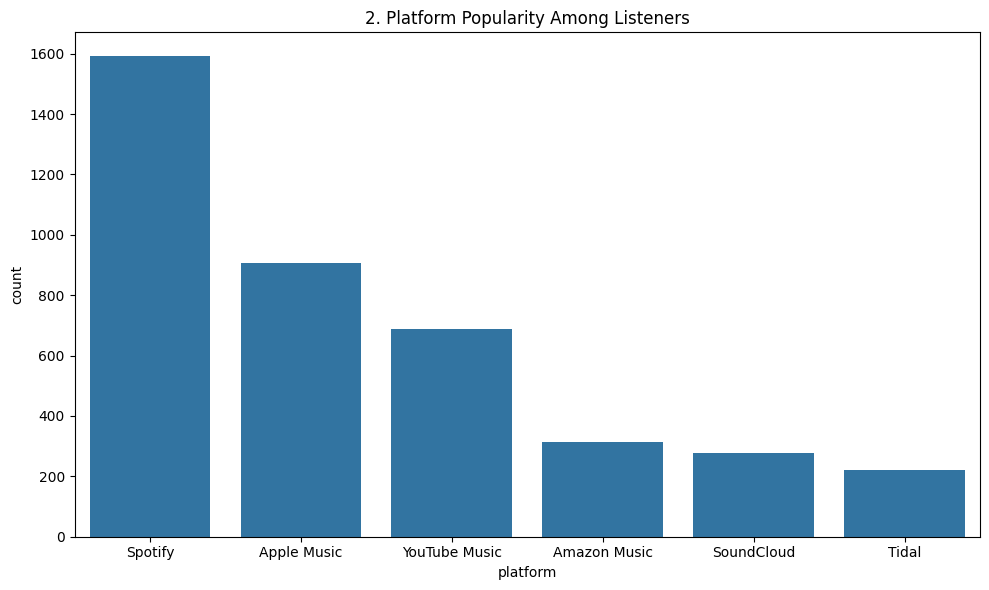

In [34]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='platform', order=df['platform'].value_counts().index)
plt.title(f'{plot_no}. Platform Popularity Among Listeners')
show_fig()
plot_no += 1

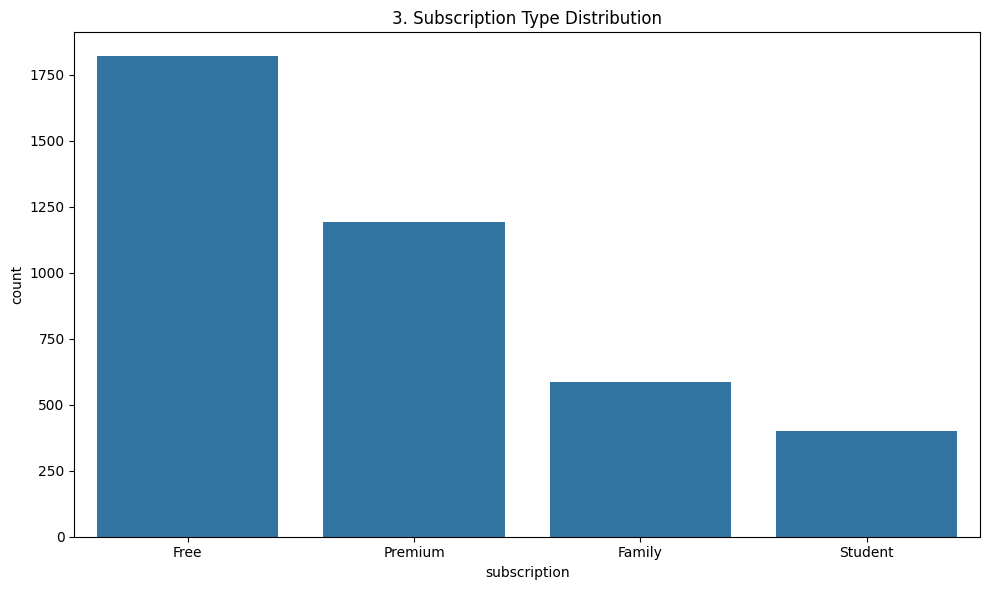

In [35]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='subscription', order=df['subscription'].value_counts().index)
plt.title(f'{plot_no}. Subscription Type Distribution')
show_fig()
plot_no += 1

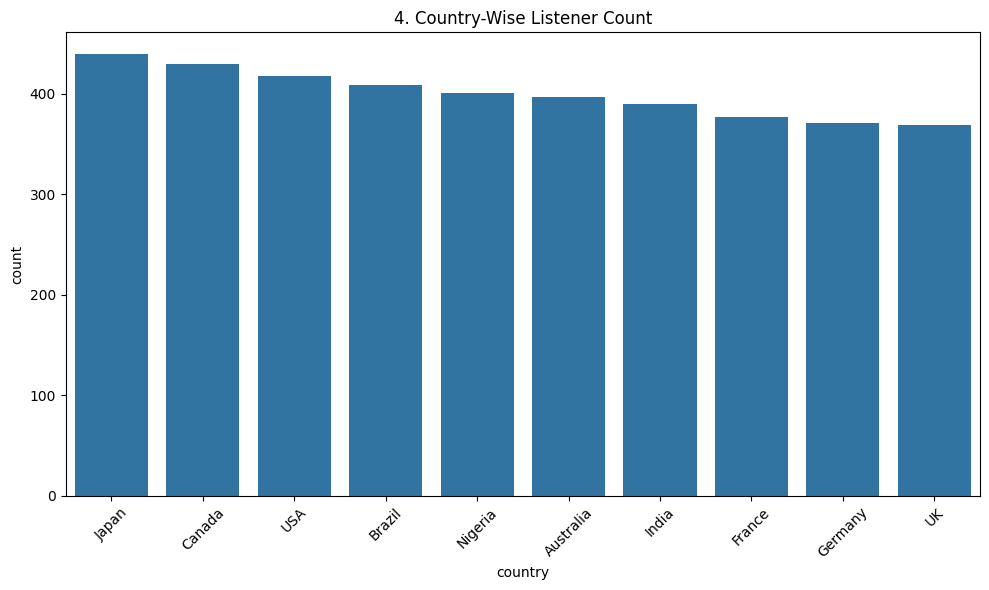

In [36]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='country', order=df['country'].value_counts().index)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Country-Wise Listener Count')
show_fig()
plot_no += 1

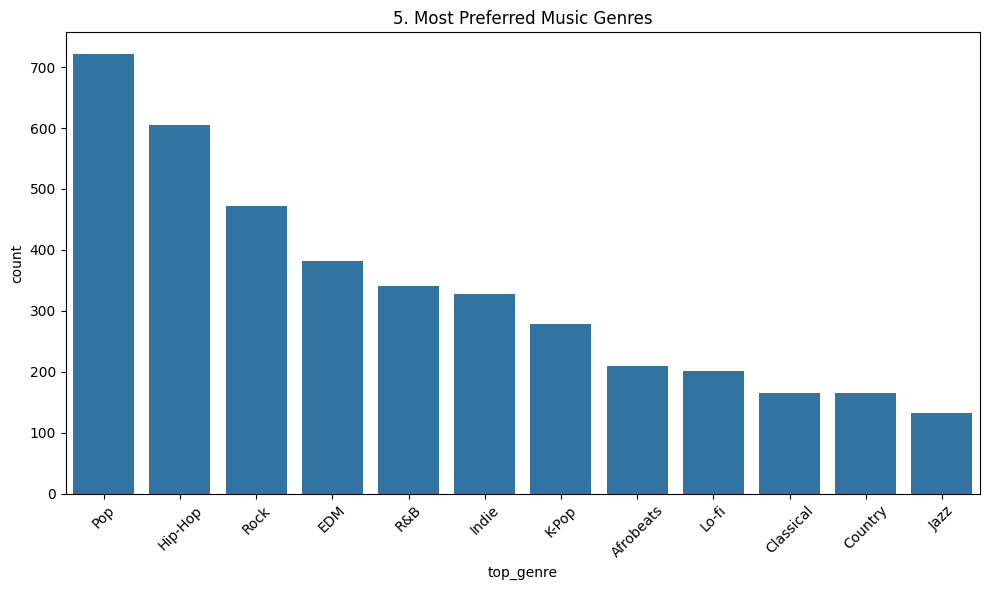

In [37]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='top_genre', order=df['top_genre'].value_counts().index)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Most Preferred Music Genres')
show_fig()
plot_no += 1

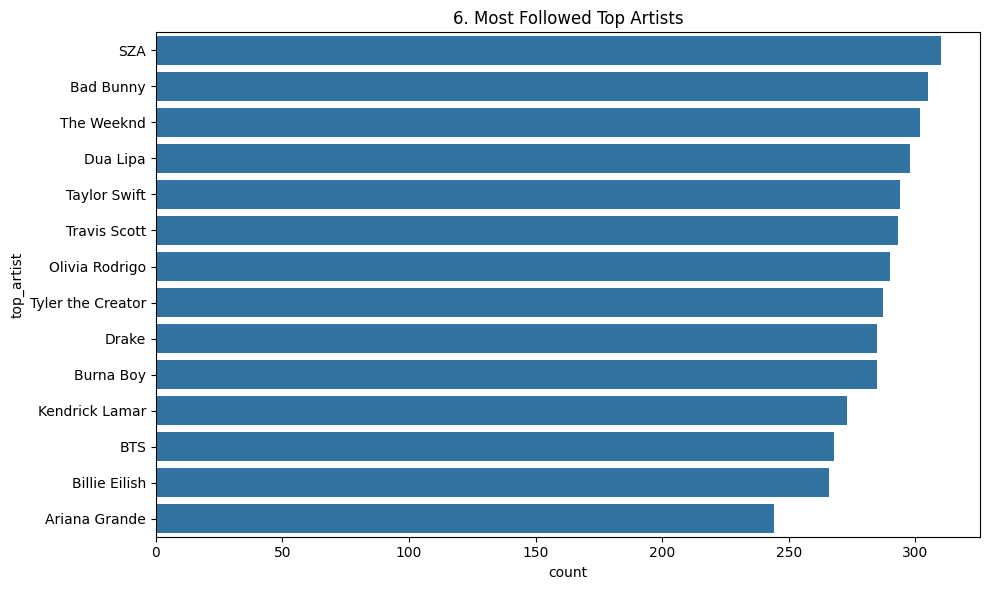

In [38]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, y='top_artist', order=df['top_artist'].value_counts().index)
plt.title(f'{plot_no}. Most Followed Top Artists')
show_fig()
plot_no += 1

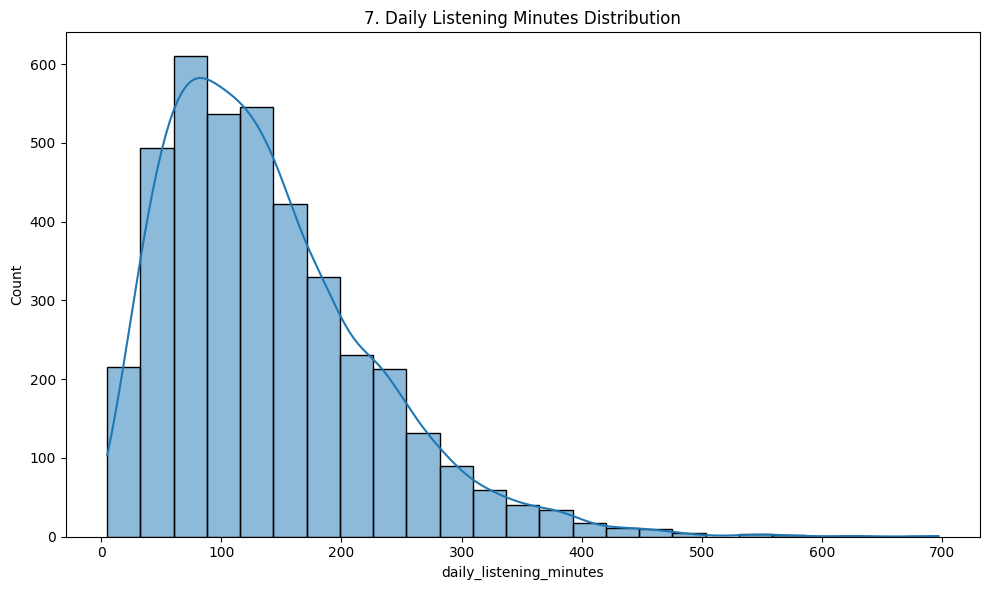

In [39]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='daily_listening_minutes', bins=25, kde=True)
plt.title(f'{plot_no}. Daily Listening Minutes Distribution')
show_fig()
plot_no += 1

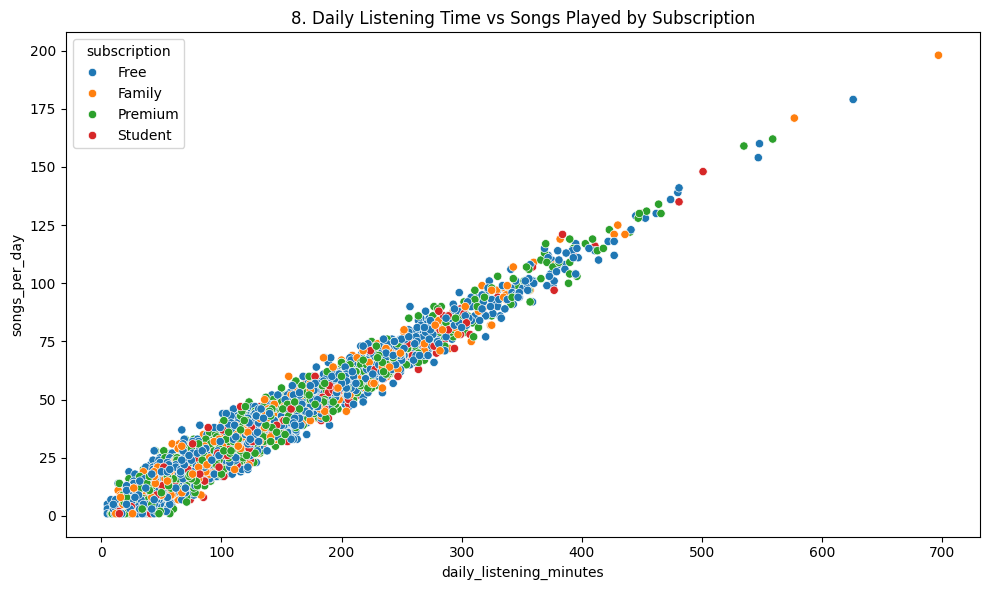

In [40]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='daily_listening_minutes', y='songs_per_day', hue='subscription')
plt.title(f'{plot_no}. Daily Listening Time vs Songs Played by Subscription')
show_fig()
plot_no += 1

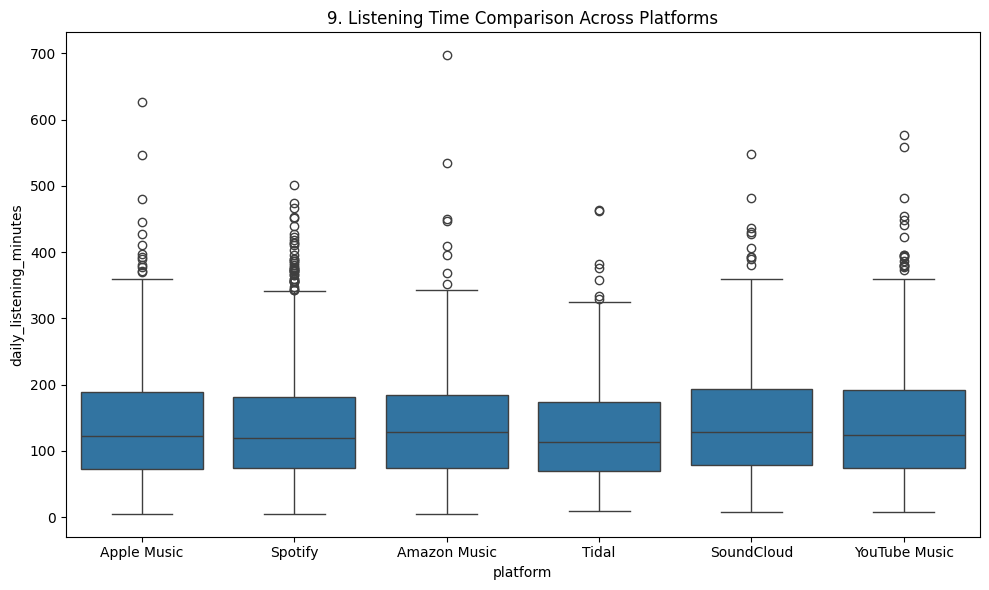

In [41]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='platform', y='daily_listening_minutes')
plt.title(f'{plot_no}. Listening Time Comparison Across Platforms')
show_fig()
plot_no += 1

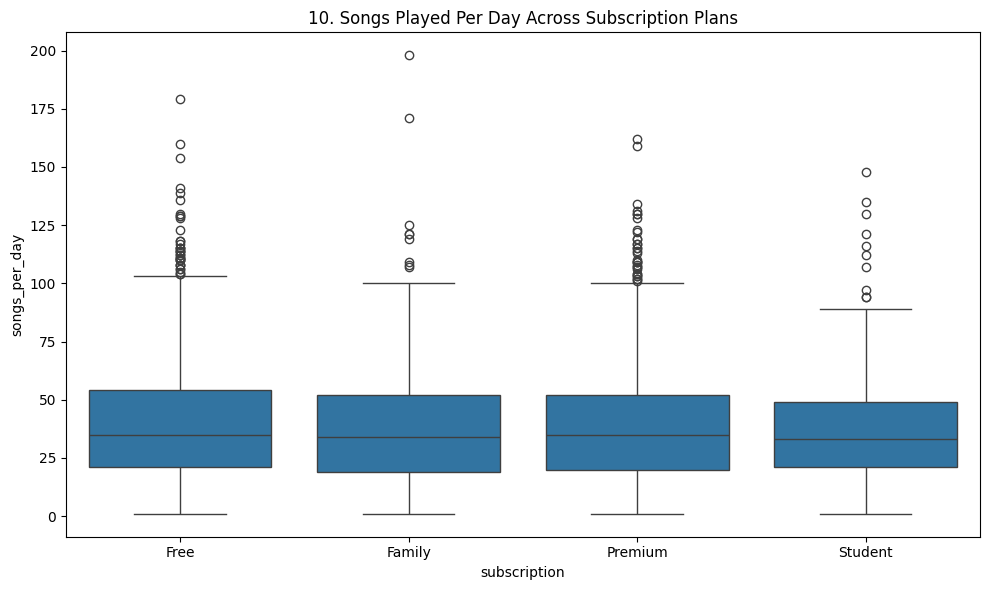

In [42]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='subscription', y='songs_per_day')
plt.title(f'{plot_no}. Songs Played Per Day Across Subscription Plans')
show_fig()
plot_no += 1

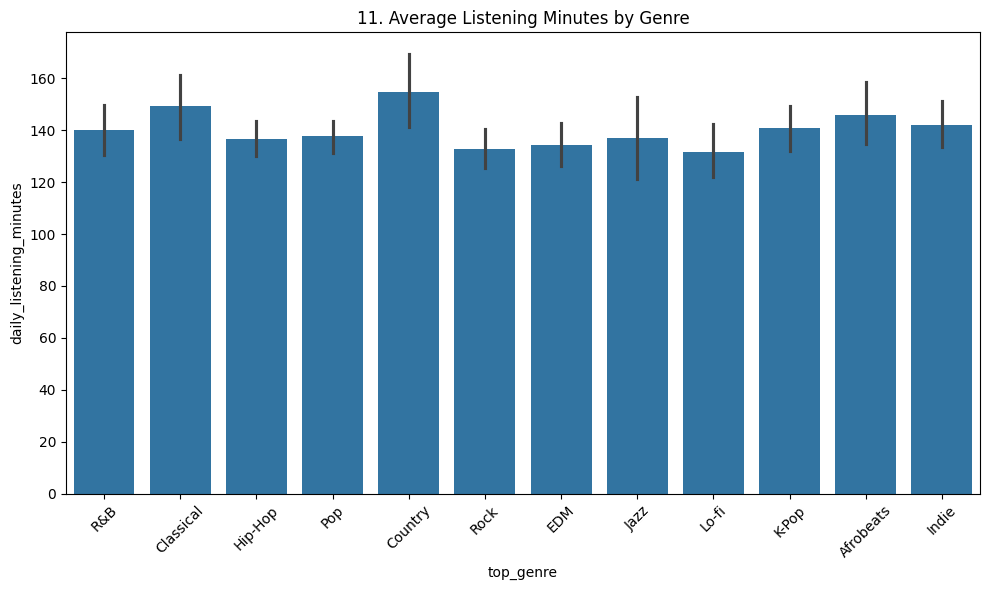

In [43]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='top_genre', y='daily_listening_minutes', estimator='mean')
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Average Listening Minutes by Genre')
show_fig()
plot_no += 1

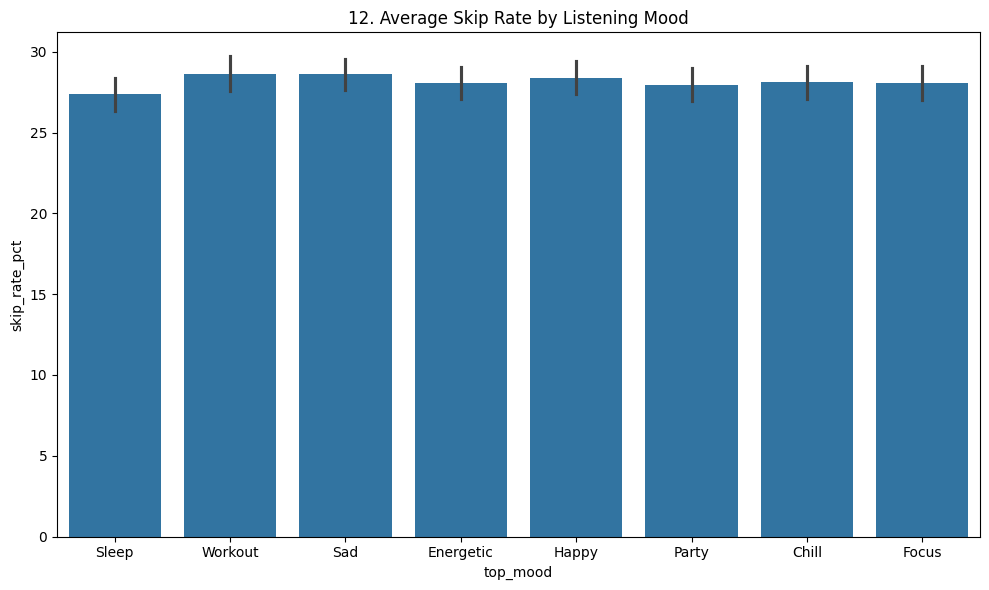

In [44]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='top_mood', y='skip_rate_pct', estimator='mean')
plt.title(f'{plot_no}. Average Skip Rate by Listening Mood')
show_fig()
plot_no += 1

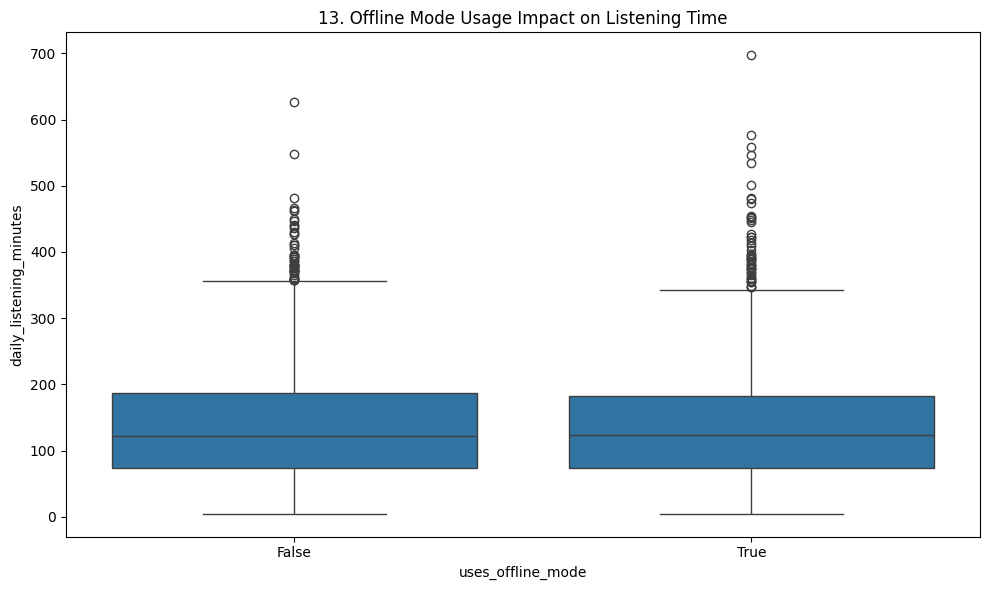

In [45]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='uses_offline_mode', y='daily_listening_minutes')
plt.title(f'{plot_no}. Offline Mode Usage Impact on Listening Time')
show_fig()
plot_no += 1

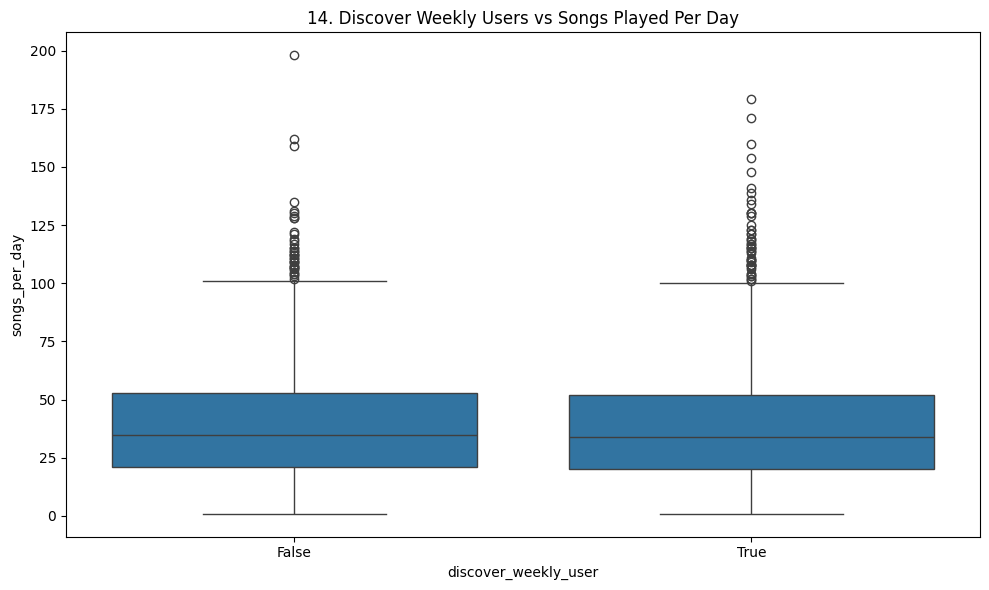

In [46]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='discover_weekly_user', y='songs_per_day')
plt.title(f'{plot_no}. Discover Weekly Users vs Songs Played Per Day')
show_fig()
plot_no += 1

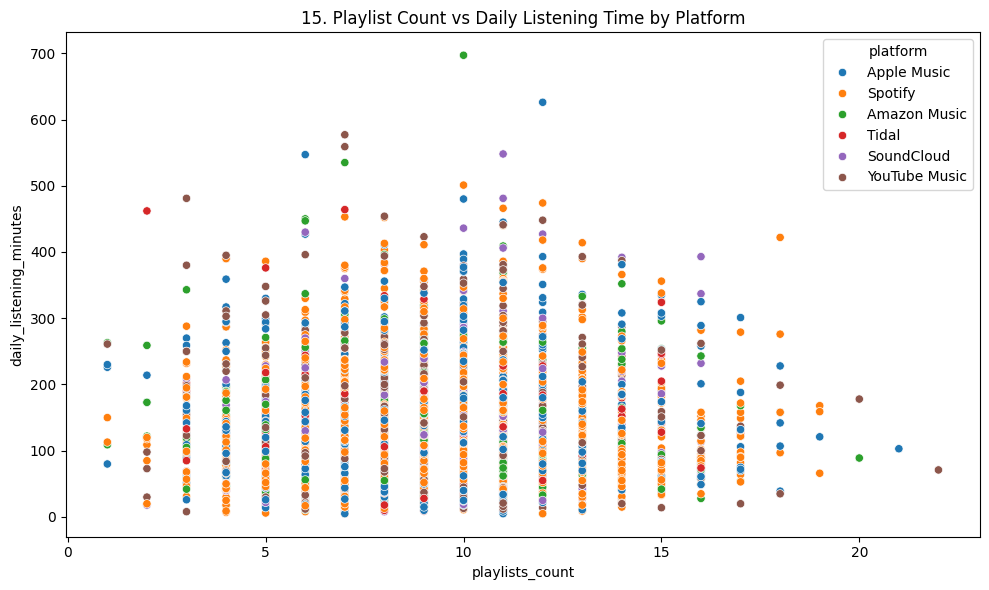

In [47]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='playlists_count', y='daily_listening_minutes', hue='platform')
plt.title(f'{plot_no}. Playlist Count vs Daily Listening Time by Platform')
show_fig()
plot_no += 1

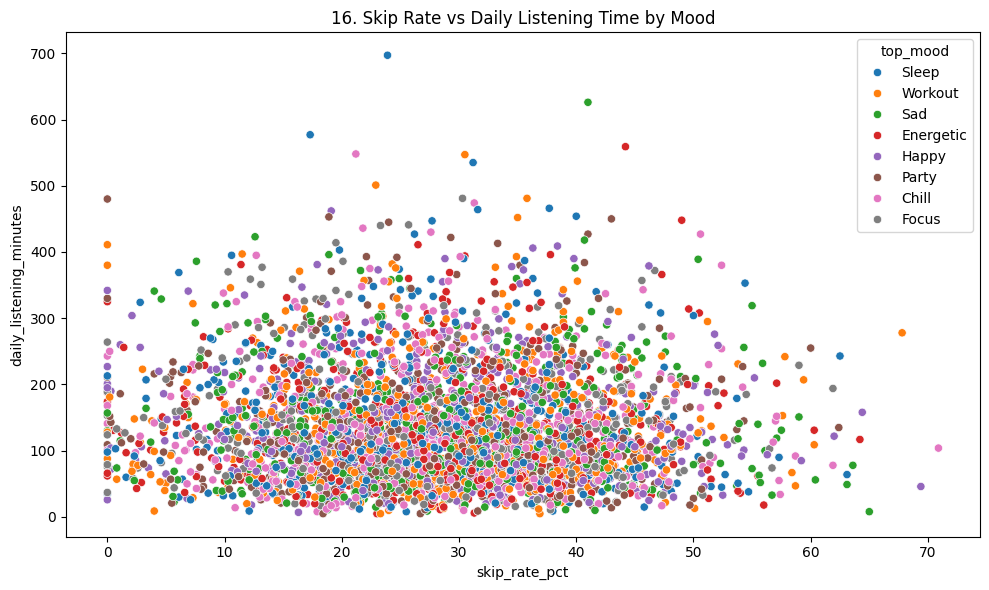

In [48]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='skip_rate_pct', y='daily_listening_minutes', hue='top_mood')
plt.title(f'{plot_no}. Skip Rate vs Daily Listening Time by Mood')
show_fig()
plot_no += 1

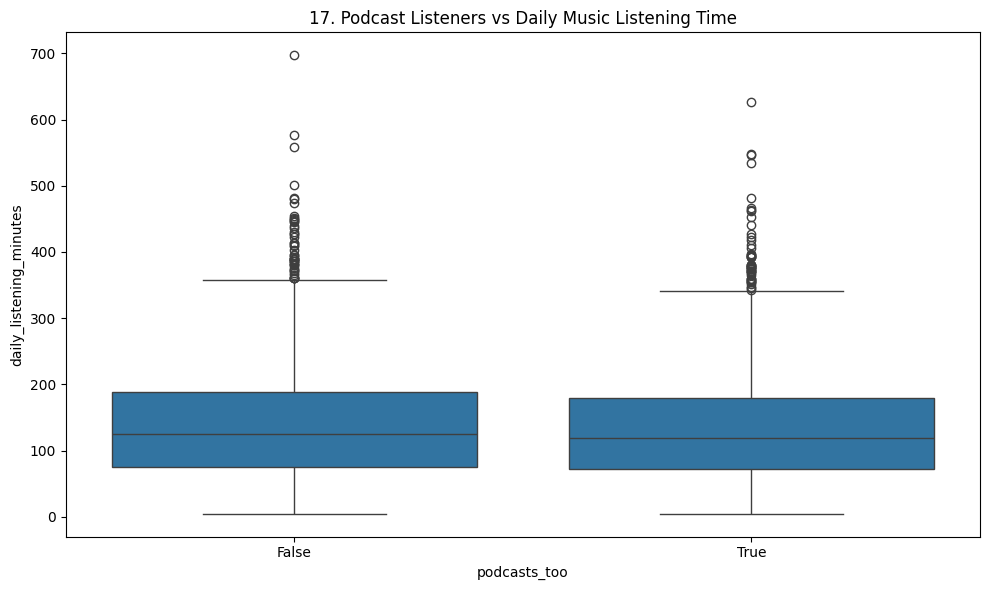

In [49]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='podcasts_too', y='daily_listening_minutes')
plt.title(f'{plot_no}. Podcast Listeners vs Daily Music Listening Time')
show_fig()
plot_no += 1

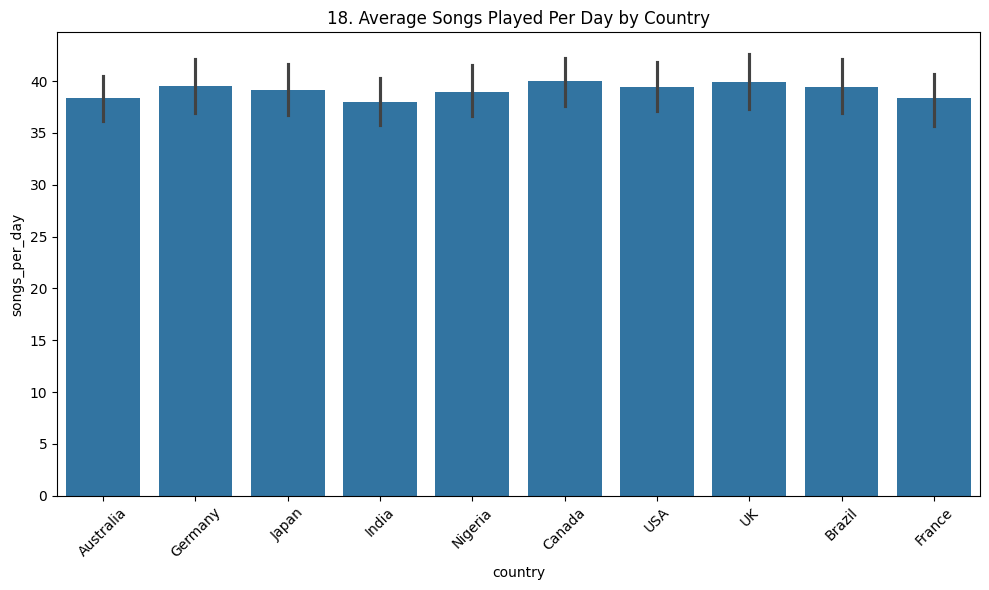

In [50]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='country', y='songs_per_day', estimator='mean')
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Average Songs Played Per Day by Country')
show_fig()
plot_no += 1

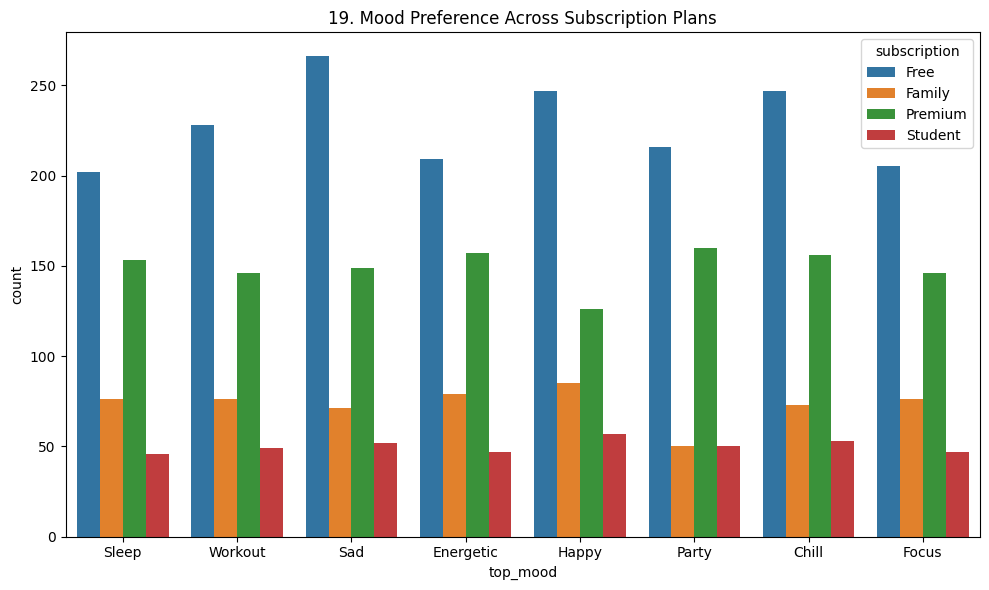

In [51]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='top_mood', hue='subscription')
plt.title(f'{plot_no}. Mood Preference Across Subscription Plans')
show_fig()
plot_no += 1

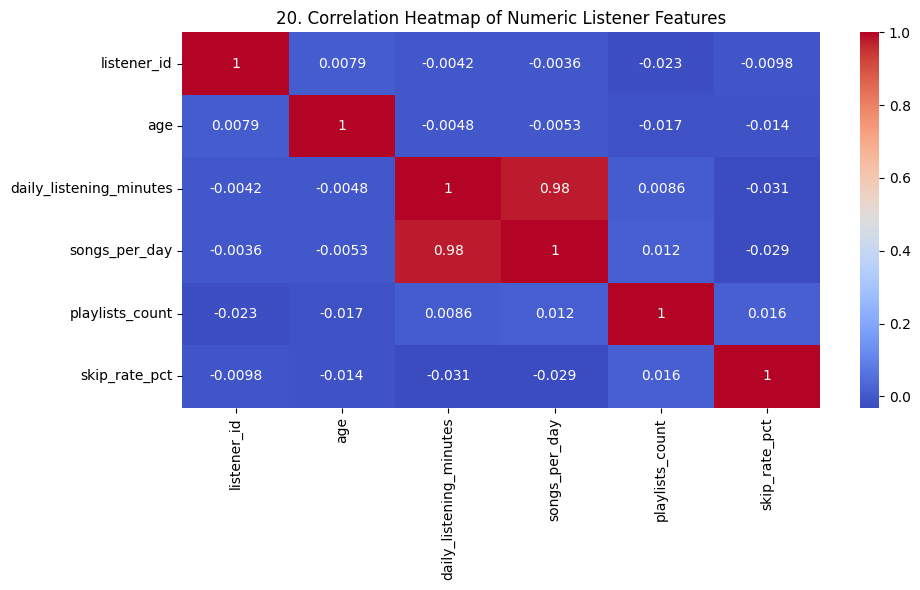

In [52]:
corr = df.select_dtypes(include='number').corr()

fig = plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numeric Listener Features')
show_fig()
plot_no += 1

# Model Training

## select target column

In [ ]:
target = 'songs_per_day'

## create input and output data

In [ ]:
X = df.drop(columns=[target, 'listener_id'])
y = df[target]

## split numerical and categorical columns

In [ ]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'bool']).columns

## create preprocessing for numerical and categorical data

In [ ]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

## create gradient boosting regression pipeline

In [ ]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

## split data into train and test parts

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## train the model

In [ ]:
model.fit(X_train, y_train)

## predict test data

In [ ]:
y_pred = model.predict(X_test)

## print model performance

In [ ]:
print("R2 Score:", round(r2_score(y_test, y_pred) * 100, 2), "%")
print("MAE:", round(mean_absolute_error(y_test, y_pred), 2))
print("MSE:", round(mean_squared_error(y_test, y_pred), 2))

## create actual and predicted dataframe

R2 Score: 95.65 %
MAE: 4.08
MSE: 25.79


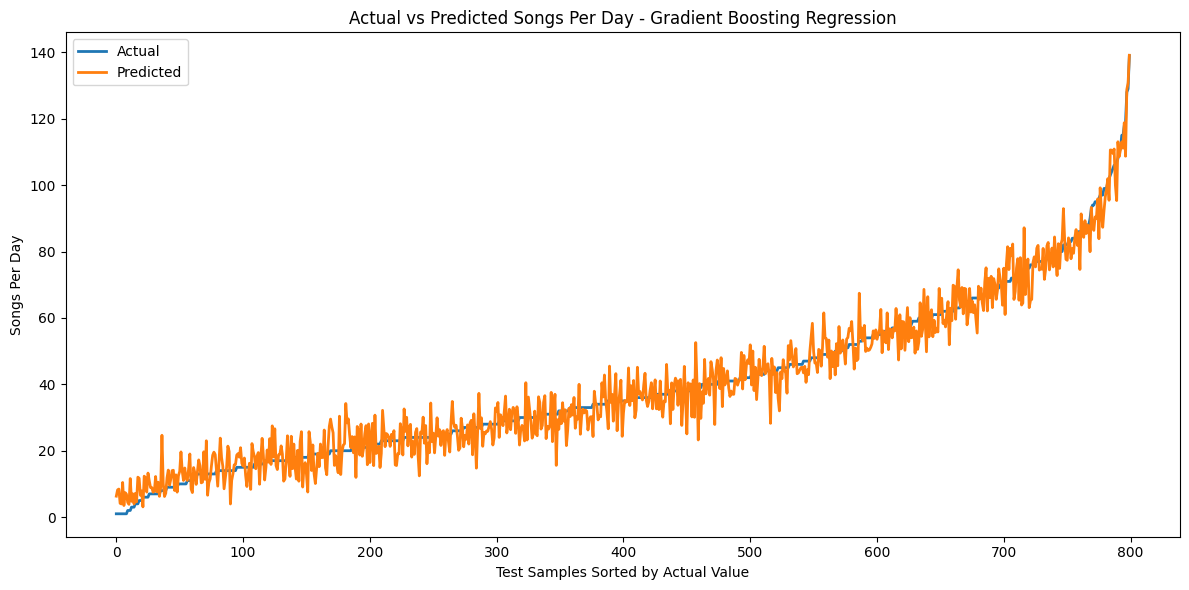

In [53]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
}).sort_values('Actual').reset_index(drop=True)

## plot actual vs predicted line chart
plt.figure(figsize=(12,6))
plt.plot(results['Actual'], label='Actual', linewidth=2)
plt.plot(results['Predicted'], label='Predicted', linewidth=2)
plt.xlabel("Test Samples Sorted by Actual Value")
plt.ylabel("Songs Per Day")
plt.title("Actual vs Predicted Songs Per Day - Gradient Boosting Regression")
plt.legend()
plt.tight_layout()
plt.show()